# Classificando Dados

## Criando modelo inicial

In [1]:
import pandas as pd 

URI = r'C:\Users\Usuario\Documents\Estudos\ALURA\05_Data_Science\raw\emp_automovel.csv'
dados = pd.read_csv(URI)

dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


In [2]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

X = dados.drop(columns='inadimplente')
y = dados['inadimplente']

dtc.fit(X, y)
print(f'Acurácia: {dtc.score(X, y)}')

Acurácia: 1.0


## Validando o modelo

In [3]:
from sklearn.model_selection import train_test_split
X, X_teste, y, y_teste = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5)
X_treino, x_validacao, y_treino, y_validacao = train_test_split(X, y, stratify=y, random_state=5)

In [4]:
dtc = DecisionTreeClassifier(max_depth=10)
dtc.fit(X_treino, y_treino)
print(f'Acurácia de Treino: {dtc.score(X_treino, y_treino)}\nAcurácia de Validação: {dtc.score(x_validacao, y_validacao)}')

Acurácia de Treino: 0.9206445993031359
Acurácia de Validação: 0.9055831373573731


## Avaliando o modelo

In [5]:
from sklearn.metrics import confusion_matrix
y_previsto = dtc.predict(x_validacao)
matriz_confusao = confusion_matrix(y_validacao, y_previsto)
print(matriz_confusao)

[[10355   124]
 [  960    42]]


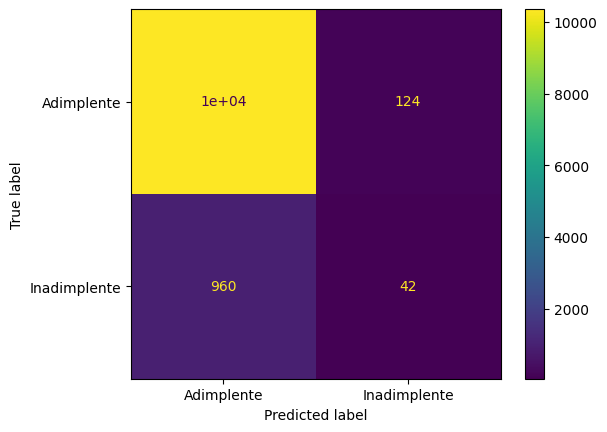

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
visualizacao.plot();

## Desafio da Aula

In [7]:
# Utilizamos durante a aula o algoritmo de árvore de decisão, 
# mas a biblioteca Scikit-Learn possui diversos outros métodos de classificação que podem ser utilizados no nosso projeto. 
# Como desafio, utilize o algoritmo Random Forest para criar um modelo e avaliar o desempenho com a acurácia e a matriz de confusão, 
# e compare os resultados com o resultado da árvore de decisão.
# from sklearn.ensemble import RandomForestClassifier

# clf = RandomForestClassifier(max_depth=2, random_state=10)
# clf.fit(X_treino, y_treino)
# print(f'Acurácia de treino: {clf.score(X_teste, y_teste)}')
# print(f'Acurácia de validação: {clf.score(x_validacao, y_validacao)}')

# y_previsto = clf.predict(x_validacao)
# matriz_confusao = confusion_matrix(y_validacao, y_previsto)
# visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=['Adimplente', 'Inadimplente'])
# visualizacao.plot();

# Métricas e Avaliações

## Acurácia, precisão e recall

In [8]:
from sklearn.metrics import accuracy_score
print(f'Acurácia: {accuracy_score(y_validacao, y_previsto)}')

Acurácia: 0.9055831373573731


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(f'Precisão: {precision_score(y_validacao, y_previsto)}')
print(f'Recall: {recall_score(y_validacao, y_previsto)}')
print(f'F1-Score: {f1_score(y_validacao, y_previsto)}')

Precisão: 0.25301204819277107
Recall: 0.041916167664670656
F1-Score: 0.07191780821917808


## Curva ROC

AUC: 0.5150414887373835


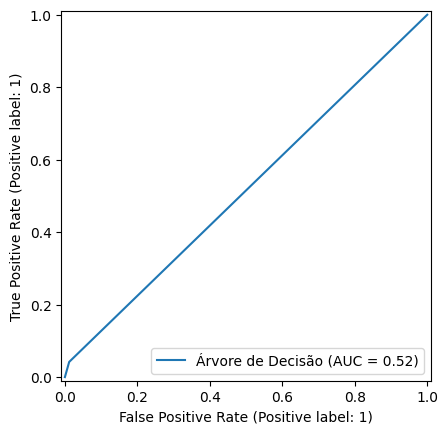

In [10]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
print(f'AUC: {roc_auc_score(y_validacao, y_previsto)}')
RocCurveDisplay.from_predictions(y_validacao, y_previsto, name='Árvore de Decisão');

## Curva de Precisão x Recall

average_precision_score: 0.09422170515363755


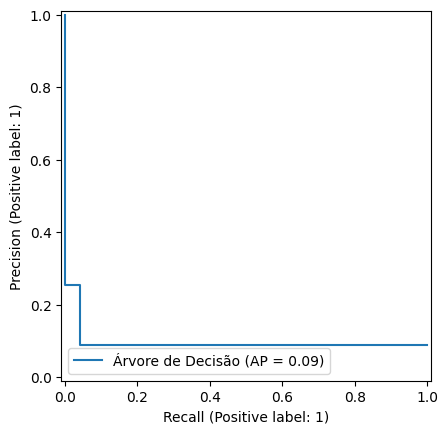

In [11]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
print(f'average_precision_score: {average_precision_score(y_validacao, y_previsto)}')
PrecisionRecallDisplay.from_predictions(y_validacao, y_previsto, name='Árvore de Decisão');

## Relatório de Métricas

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_validacao, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.25      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.58      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



# Validação Cruzada

## KFOLD

In [13]:
from sklearn.model_selection import cross_validate, KFold

dtc = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(dtc, X, y, cv=kf)
cv_resultados

{'fit_time': array([0.13804984, 0.13376594, 0.13720703, 0.14373231, 0.13965249]),
 'score_time': array([0.0021348 , 0.00197768, 0.00203109, 0.00201249, 0.00198436]),
 'test_score': array([0.91311922, 0.90777439, 0.90733885, 0.91387195, 0.89960801])}

In [14]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'Intervalo de confiança: [{media-2*desvio_padrao}, {min(media+2*desvio_padrao, 1)}]')

Intervalo de confiança: [0.8981047831870108, 0.9185801854882456]


## Recall

In [15]:
def intervalo_conf(resultados, coluna:str = 'test_score'):
    media = resultados[coluna].mean()
    desvio_padrao = resultados[coluna].std()
    print(f'Intervalo de confiança: [{media-2*desvio_padrao}, {min(media+2*desvio_padrao, 1)}]')

In [16]:
dtc = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(dtc, X, y, cv=kf, scoring='recall')
cv_resultados

{'fit_time': array([0.15087175, 0.14422965, 0.14387655, 0.13661575, 0.13507938]),
 'score_time': array([0.00349402, 0.00399232, 0.00352335, 0.00342727, 0.00341964]),
 'test_score': array([0.02642008, 0.01980198, 0.0196802 , 0.01827676, 0.02312139])}

In [17]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.015566876652899218, 0.027353285725321325]


## Desafio da Aula

In [18]:
# Como desafio, construa um código para gerar o intervalo de confiança para cada uma das métricas com a utilização da validação cruzada:
#Acurácia, Recall, Precisão, F1-score
import sklearn
sklearn.metrics.get_scorer_names()

dtc = DecisionTreeClassifier(max_depth=10)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(dtc, X, y, cv=kf, scoring=('accuracy', 'recall', 'precision', 'f1'))
cv_resultados

{'fit_time': array([0.14027882, 0.13856912, 0.13761926, 0.13582754, 0.13528347]),
 'score_time': array([0.00863886, 0.00809097, 0.00791717, 0.00779915, 0.0085659 ]),
 'test_accuracy': array([0.91322809, 0.90733885, 0.90766551, 0.91332753, 0.89906359]),
 'test_recall': array([0.02774108, 0.01732673, 0.02091021, 0.01436031, 0.02543353]),
 'test_precision': array([0.25609756, 0.1971831 , 0.24637681, 0.21153846, 0.20754717]),
 'test_f1': array([0.05005959, 0.03185438, 0.03854875, 0.02689487, 0.04531411])}

In [19]:
intervalo_conf(cv_resultados, 'test_accuracy')
intervalo_conf(cv_resultados, 'test_recall')
intervalo_conf(cv_resultados, 'test_precision')
intervalo_conf(cv_resultados, 'test_f1')

Intervalo de confiança: [0.8976922189632924, 0.9185572049004148]
Intervalo de confiança: [0.011252227823581713, 0.031056517906856533]
Intervalo de confiança: [0.1774816480692509, 0.27001559293520677]
Intervalo de confiança: [0.021589814331553065, 0.05547886657198946]


## Estratificando os dados

In [20]:
dados['inadimplente'].value_counts(normalize=True)

inadimplente
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [21]:
from sklearn.model_selection import StratifiedKFold

dtc = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(dtc, X, y, cv=skf, scoring='recall')
cv_resultados

{'fit_time': array([0.14718223, 0.13432932, 0.13676548, 0.13347673, 0.13646102]),
 'score_time': array([0.00399375, 0.00361156, 0.003649  , 0.00347853, 0.00350761]),
 'test_score': array([0.0361596 , 0.02871411, 0.0286783 , 0.02618454, 0.02618454])}

In [22]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.021855967272818713, 0.03651246869095475]


# Balanceamento de Dados

## Oversampling

In [23]:
!pip install imblearn --quiet

In [ ]:
from imblearn.over_sampling import SMOTE

In [25]:
oversample = SMOTE()
X_balanceado, y_balanceado = oversample.fit_resample(X=X, y=y)

In [28]:
y_balanceado.value_counts(normalize=True)

inadimplente
0    0.5
1    0.5
Name: proportion, dtype: float64

In [29]:
dtc = DecisionTreeClassifier(max_depth=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(dtc, X_balanceado, y_balanceado, cv=skf, scoring='recall')
cv_resultados

{'fit_time': array([0.29894018, 0.29610038, 0.28968811, 0.29285383, 0.30216527]),
 'score_time': array([0.00673175, 0.00489259, 0.00484991, 0.00477552, 0.00470567]),
 'test_score': array([0.74791219, 0.72763064, 0.70022665, 0.72456161, 0.70496302])}

In [30]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.6867704420074866, 0.7553472011200745]


## Pipeline para validação

In [31]:
from imblearn.pipeline import Pipeline as imbpipeline

dtc = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arvore', dtc)])

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall')
cv_resultados

{'fit_time': array([0.32575774, 0.32232761, 0.32605314, 0.3230648 , 0.3239553 ]),
 'score_time': array([0.00423217, 0.00431967, 0.00404453, 0.00392914, 0.00427294]),
 'test_score': array([0.30299252, 0.26342072, 0.27306733, 0.27182045, 0.21321696])}

In [33]:
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.2066698399037306, 0.32313735247736414]


## Undersampling

In [35]:
from imblearn.under_sampling import NearMiss

dtc = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arvore', dtc)])
skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring = 'recall')
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.6232219758758816, 0.698288853791523]


## Testando o modelo

In [37]:
undersample = NearMiss(version=3)
X_balanceado, y_balanceado = undersample.fit_resample(X, y)

modelo = DecisionTreeClassifier(max_depth = 10)
modelo.fit(X_balanceado, y_balanceado)
y_previsto = modelo.predict(X_teste)

print(classification_report(y_teste, y_previsto))

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



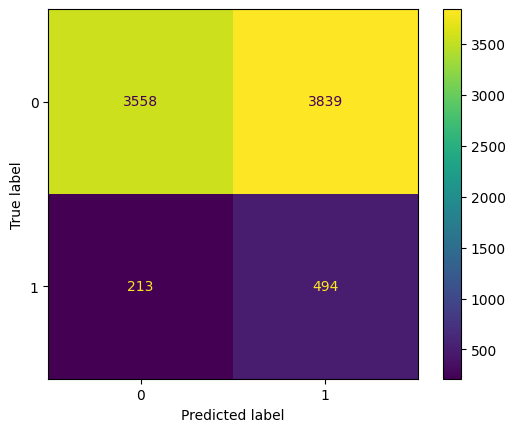

In [38]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_previsto);

# Desafio da Aula

In [39]:
# Como desafio, utilize o algoritmo SMOTEENN, que combina o oversampling com SMOTE e undersampling com o ENN (Edited Nearest Neighbours), 
# para balancear os dados e perceba os resultados obtidos pelo modelo usando o pipeline e a validação cruzada.
from imblearn.combine import SMOTEENN

dtc = DecisionTreeClassifier(max_depth = 10)
pipeline = imbpipeline([('smoteenn', SMOTEENN()), ('arvore', dtc)])

skf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring = 'recall')
intervalo_conf(cv_resultados)

Intervalo de confiança: [0.34279486565328926, 0.38457335549172583]
